In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Replacing blanks in TotalCharges with 0 as tenure is 0 and no total charges are recorded.

In [3]:
df["TotalCharges"]  = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum().sum()

0

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [19]:
df["customerID"].duplicated().sum()

0

# Converting 0 and 1 values of senior citizen to yes/no to make it easier to understand.

In [48]:
def conv(values):
    if values ==1:
       return "yes"
    else :
        return "no"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

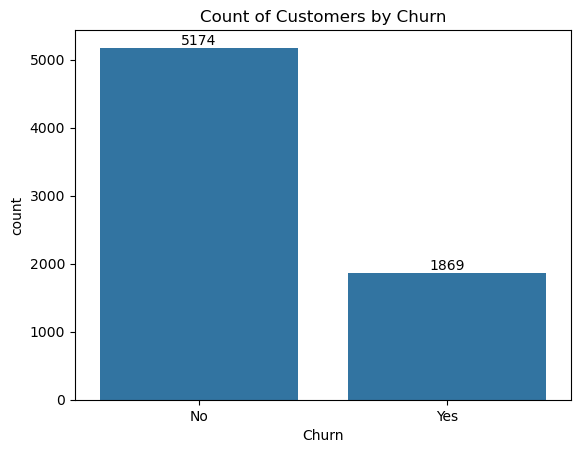

In [49]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

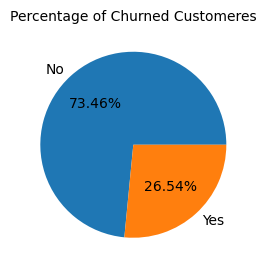

In [21]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':'count'})
plt.pie(gb['Churn'],labels =gb.index,autopct = "%1.2f%%")
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()


# from the given pie chart we can conclude that 26.54% of our customers have churned out.

# Now let's explore the reason behind it

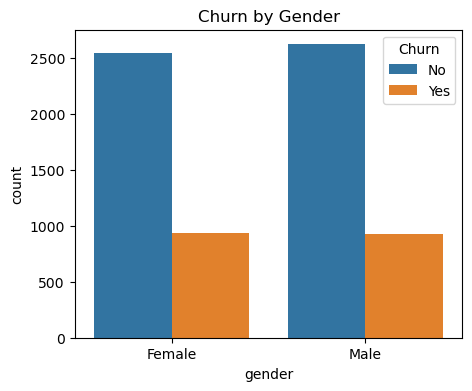

In [26]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='gender',data=df,hue="Churn")
plt.title("Churn by Gender")
plt.show()

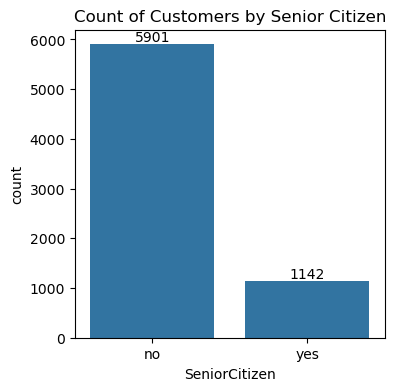

In [61]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen")
plt.show()

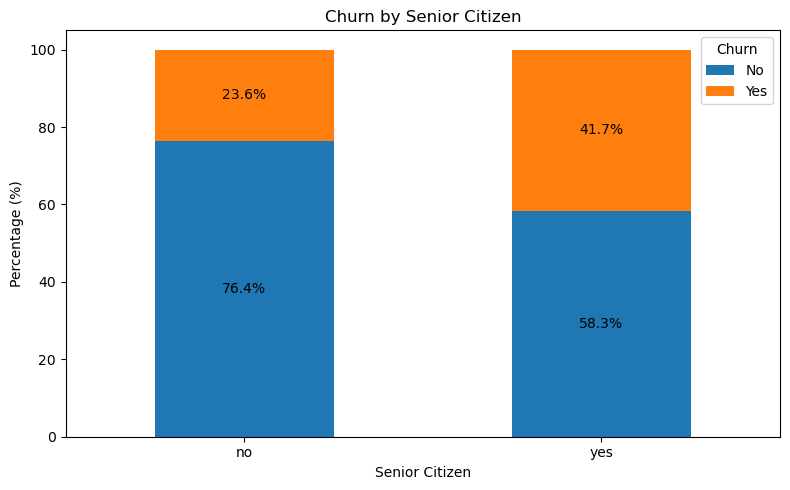

In [60]:

counts = df.groupby(["SeniorCitizen", "Churn"]).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
ax = percentages.plot(kind="bar", stacked=True, figsize=(8,5), color=["#1f77b4", "#ff7f0e"])
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')
plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

Comparative a greater pecentage of people in senior citizen category have churned.

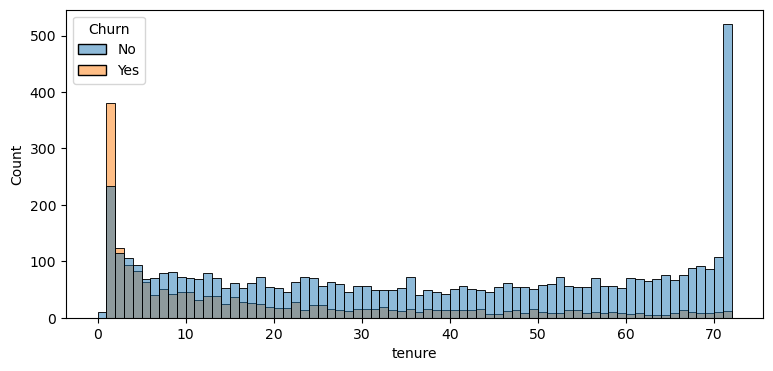

In [62]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.show()

A large portion of customers with a tenure of 70+ months did not churn (seen as a tall grey/blue bar).
For customers with low tenure (e.g., 1-2 months), there is a noticeable orange bar, indicating a higher churn rate in this group.


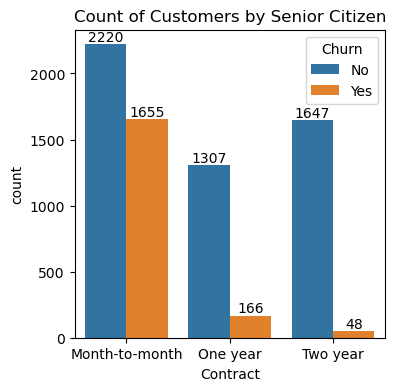

In [69]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df,hue="Churn")
for container in ax.containers:ax.bar_label(container)
plt.title("Count of Customers by Senior Citizen")
plt.show()

People who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 


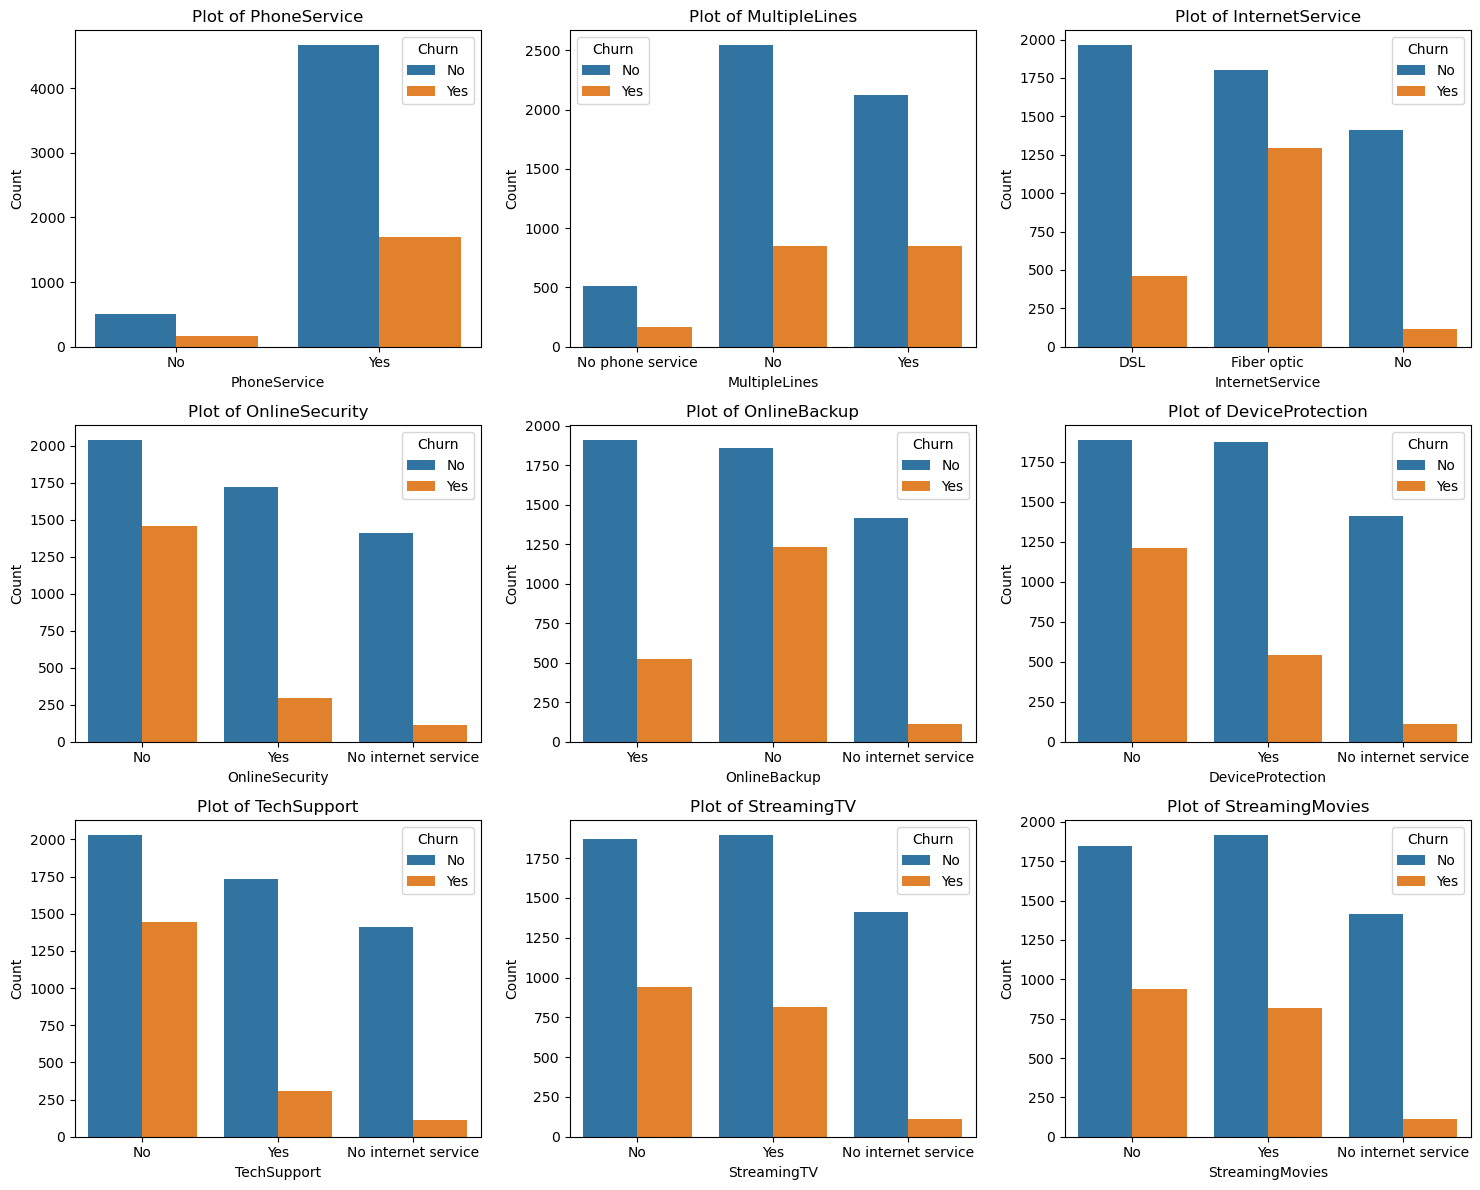

In [77]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4)) 
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


1. PhoneService alone doesn't seem to be a major factor affecting churn, as most churn comes from customers who have PhoneService.
2. Having MultipleLines may slightly increase the likelihood of churn, potentially due to higher costs or complexity in services.
3. iber Optic customers may churn more due to higher costs or service issues.DSL users are more stable, and those without internet service     are not at risk of churn.
4. OnlineSecurity is an important factor in customer retention. Customers without this service are more likely to churn.
5. OnlineBackup adds value to customers and helps in retaining them.
6. Offering DeviceProtection as part of service packages can reduce churn.
7. TechSupport plays a significant role in customer satisfaction and retention.
8. StreamingTV might not be a strong retention factor, and dissatisfaction with this service could lead to churn.
9. StreamingMovies may not significantly contribute to customer retention. Improvement in service quality or better bundling could help reduce churn.


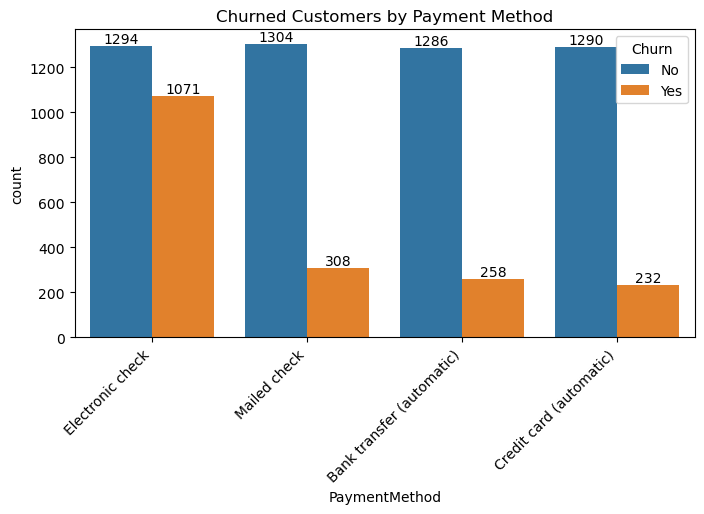

In [92]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x="PaymentMethod",data = df,hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.show()
